In [ ]:
import google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Transcriptformer

In [ ]:
!pip install transcriptformer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.3/478.3 kB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of aiobotocore to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of aiobotocore to determine which version is compat

## Torch

In [ ]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [ ]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 \
--index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 24.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 116.1 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

import torchvision.ops
print("OK ✔")

2.5.1+cu124
0.20.1+cu124
OK ✔


# Imports

In [ ]:
!pip install mygene
!pip install scanpy
# !pip uninstall -y zarr
# !pip install "zarr<3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import warnings
import mygene
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

model_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/tf_exemplar"
data_dir = "/content/drive/MyDrive/gp/data"

# Imports for classification models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import warnings


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [ ]:
def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

# Set up evaluation function

We set up the evaluation function, we mainly compare the integration performance on avgBIO and avgBATCH. Refer to our manuscript for more details.

In [ ]:
!pip install harmonypy scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source o

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values

        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

# Lung dataset Integration

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/integration/lung

## Data preprocessing

In [ ]:
lung_data_path = os.path.join(data_dir, "GP_datasets/Lung/Lung_combined.h5ad")
adata = sc.read_h5ad(lung_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 13117
    obs: 'cell_type', 'dataset', 'source'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['dataset'].unique()

['Dataset1', 'Dataset2']
Categories (2, object): ['Dataset1', 'Dataset2']

In [ ]:
adata.var.index

Index(['LINC00115', 'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4',
       'ISG15', 'AGRN', 'RNF223',
       ...
       'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=13117)

In [ ]:
mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")
print(adata.var.head())



In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 13117
    obs: 'cell_type', 'dataset', 'source'
    var: 'ensembl_id'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['assay'] = '10x Genomics'


In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 13117
    obs: 'cell_type', 'dataset', 'source', 'assay'
    var: 'ensembl_id'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.write(os.path.join(data_dir, "lung/lung.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(data_dir, "lung/lung.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/lung"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
adata=sc.read_h5ad(data)

In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 13117
    obs: 'cell_type', 'dataset', 'source', 'assay'
    var: 'ensembl_id'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_lung_integration_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-04-21 12:30:59,808 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-04-21 12:31:00,937 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-04-21 12:31:50,331 -

In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 13117
    obs: 'cell_type', 'dataset', 'source', 'assay'
    var: 'ensembl_id'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_lung_integration_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 0
    obs: 'cell_type', 'dataset', 'source', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[ 0.02115014,  0.0709524 ,  0.05022983, ...,  0.03844457,
         0.00901639,  0.01839579],
       [-0.00153386,  0.11014586,  0.05706451, ..., -0.01387788,
         0.02136762,  0.00316869],
       [ 0.01463739,  0.25748175, -0.4150633 , ...,  0.06681951,
        -0.03376386,  0.04650979],
       ...,
       [-0.01257385,  0.07333313, -0.05475583, ..., -0.01480708,
         0.04026654,  0.02403684],
       [-0.02400495,  0.06314734, -0.06563461, ..., -0.02375694,
         0.03003103,  0.01355761],
       [-0.01506717,  0.11354677, -0.05949014, ..., -0.03126252,
         0.06765598,  0.02466609]], shape=(65129, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_lung_integration_embeddings.h5ad"))

## Visualize the integration performance

In [ ]:
adata=sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_lung_integration_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 0
    obs: 'cell_type', 'dataset', 'source', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

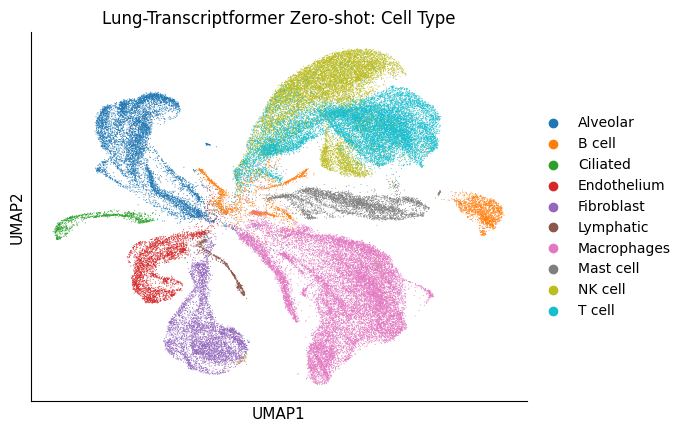

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Lung-Transcriptformer Zero-shot: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

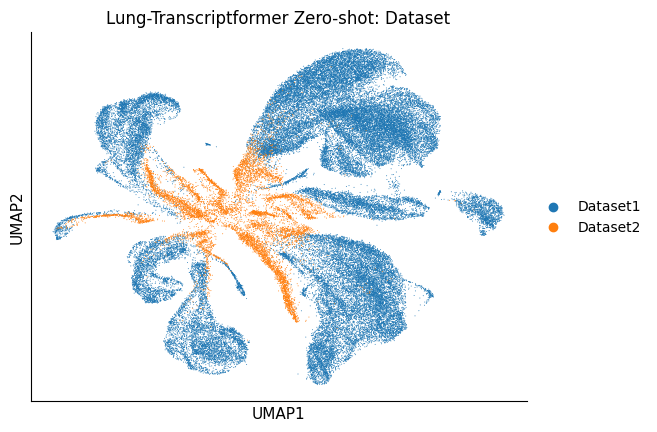

In [ ]:
ax = sc.pl.umap(
    adata,
    color='dataset',
    frameon=True,
    title=[
        "Lung-Transcriptformer Zero-shot: Dataset"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Evaluate the integration performance

In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 0
    obs: 'cell_type', 'dataset', 'source', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
label_keys = ["cell_type", "dataset"]
scores = compute_silhouette_and_lisi_avg(adata, label_keys,embed_key="X_transcriptformer")

print("Silhouette scores:", scores["silhouette"])
print("LISI scores:", scores["lisi"])

## Label Transfer

In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 0
    obs: 'cell_type', 'dataset', 'source', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['dataset'].value_counts()

,count
dataset,
Dataset1,56134
Dataset2,8995


In [ ]:
train_data = adata[adata.obs['dataset'] == 'Dataset1'].copy()
test_data  = adata[adata.obs['dataset'] == 'Dataset2'].copy()

X_train = train_data.obsm["X_transcriptformer"]
X_test  = test_data.obsm["X_transcriptformer"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [ ]:
adata

AnnData object with n_obs × n_vars = 65129 × 0
    obs: 'cell_type', 'dataset', 'source', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.7765425236242357
              precision    recall  f1-score   support

    Alveolar       0.68      0.92      0.78      1834
      B cell       0.72      0.06      0.12      1250
    Ciliated       0.99      0.99      0.99       433
 Endothelium       0.86      0.96      0.91       360
  Fibroblast       0.90      0.90      0.90       204
   Lymphatic       1.00      0.73      0.84       195
 Macrophages       0.83      0.94      0.88      2878
   Mast cell       0.96      0.95      0.96       660
     NK cell       0.80      0.33      0.47       354
      T cell       0.58      0.82      0.68       827

    accuracy                           0.78      8995
   macro avg       0.83      0.76      0.75      8995
weighted avg       0.78      0.78      0.73      8995



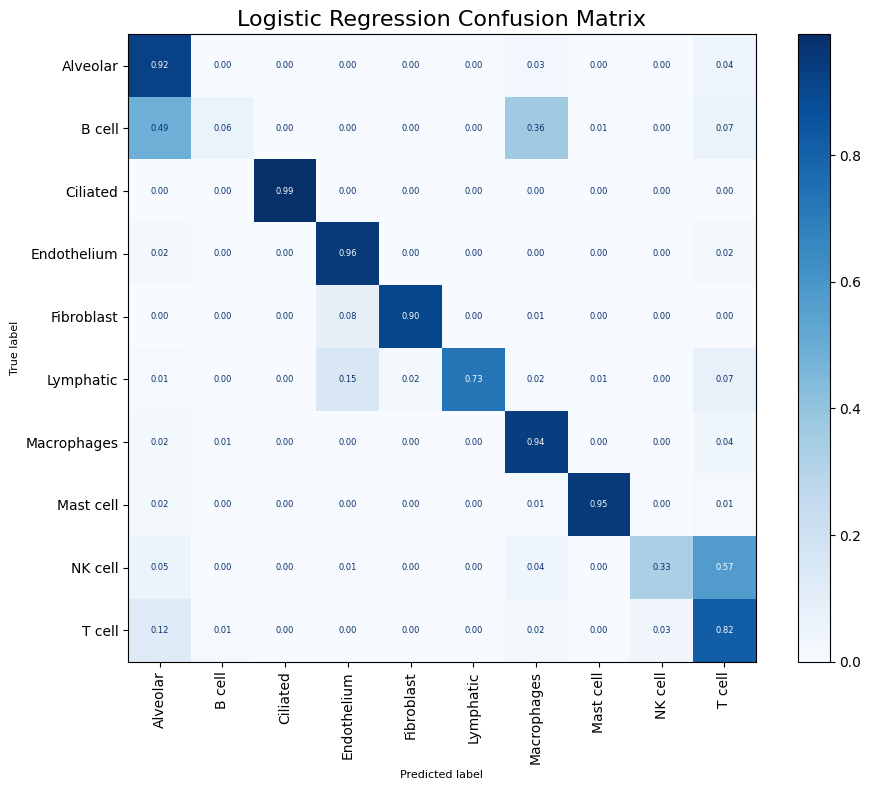


=== k-NN ===
Accuracy: 0.796887159533074
              precision    recall  f1-score   support

    Alveolar       0.72      0.93      0.81      1834
      B cell       0.82      0.05      0.09      1250
    Ciliated       0.99      0.99      0.99       433
 Endothelium       0.83      0.96      0.89       360
  Fibroblast       0.84      0.88      0.86       204
   Lymphatic       1.00      0.77      0.87       195
 Macrophages       0.83      0.96      0.89      2878
   Mast cell       0.94      0.97      0.95       660
     NK cell       0.54      0.67      0.60       354
      T cell       0.73      0.80      0.76       827

    accuracy                           0.80      8995
   macro avg       0.82      0.80      0.77      8995
weighted avg       0.81      0.80      0.75      8995



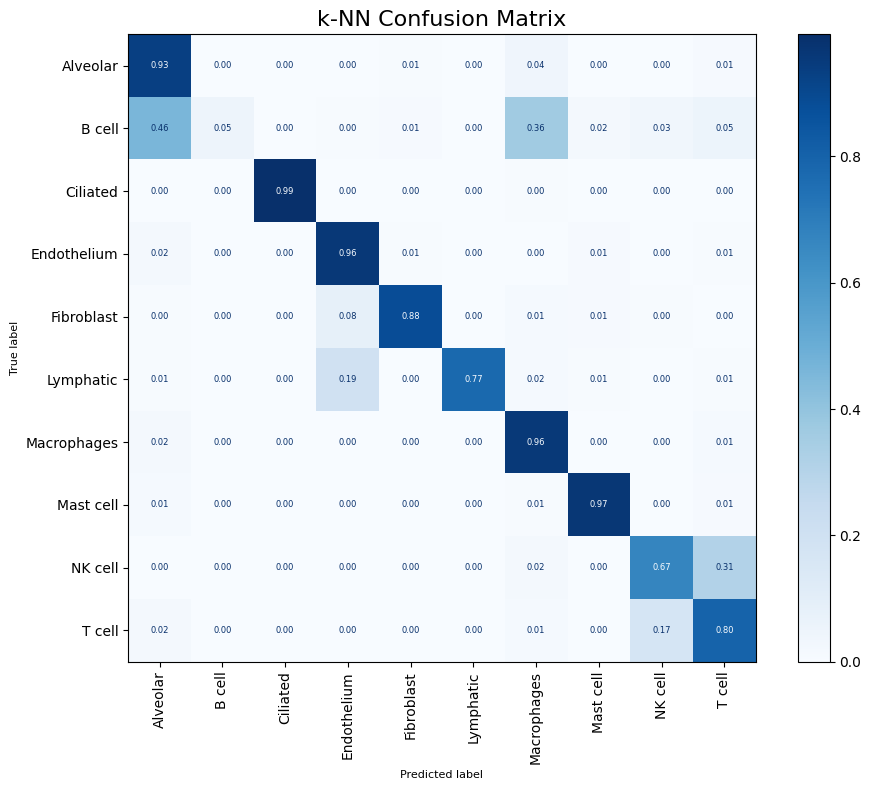

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

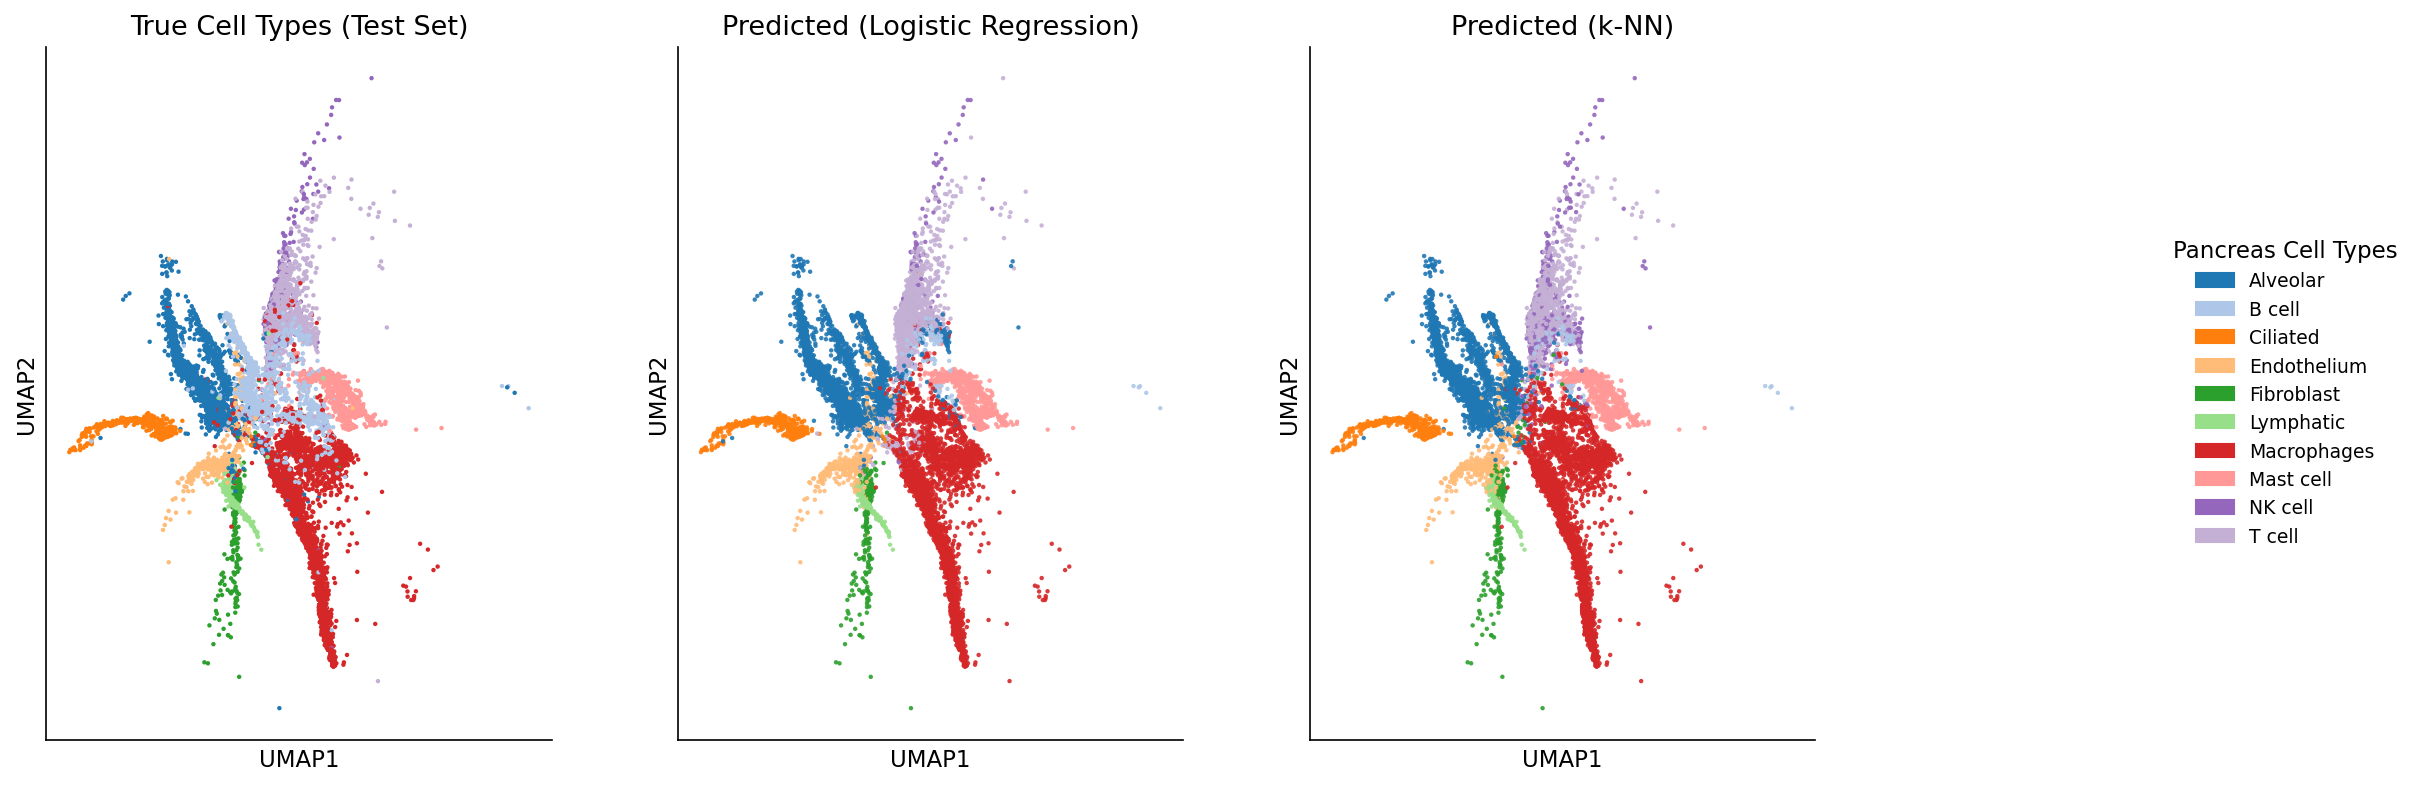

In [ ]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()

# Pancreas dataset Integration

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/integration/pancreas

## Data preprocessing

In [ ]:
pancreas_data_path = os.path.join(data_dir, "GP_datasets/Pancreas/Baron_Pancreas_Human_mix.h5ad")
adata = sc.read_h5ad(pancreas_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'

In [ ]:
adata.obs["batch"] = "healthy"
adata.obs.loc[adata.obs["donor_id"] == 'human4', "batch"] = "diseased"

In [ ]:
adata.var.index

Index(['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AA06', 'AAAS',
       'AACS', 'AACSP1',
       ...
       'SPRYD4', 'SPRYD7', 'SPSB1', 'SPSB2', 'SPSB3', 'SPSB4', 'SPTA1',
       'SPTAN1', 'SPTB', 'SPTBN1'],
      dtype='object', length=16381)

In [ ]:
mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")
print(adata.var.head())



In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch'
    var: 'ensembl_id'

In [ ]:
adata.obs['assay'] = 'inDrop'


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    var: 'ensembl_id'

In [ ]:
adata.obs['batch'].unique()

array(['healthy', 'diseased'], dtype=object)

In [ ]:
adata.write(os.path.join(data_dir, "pancreas/pancreas_mix.h5ad"))

## Get embeddings

In [ ]:
data=os.path.join(data_dir, "pancreas/pancreas_mix.h5ad")
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/pancreas"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
adata=sc.read_h5ad(data)

In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    var: 'ensembl_id'

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_pancreas_mix_integration_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-04-21 17:34:47,677 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-04-21 17:34:48,550 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-04-21 17:35:27,977 -

In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    var: 'ensembl_id'

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_pancreas_mix_integration_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 0
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[ 0.28697163, -0.01803816,  0.28272665, ...,  0.04126265,
         0.4620528 ,  0.53840774],
       [ 0.31168908, -0.01756211,  0.20266841, ..., -0.07505377,
         0.3119067 ,  0.50506175],
       [ 0.251566  ,  0.01737718,  0.23422797, ...,  0.2106314 ,
         0.30306587,  0.34666118],
       ...,
       [ 0.04981131,  0.12551089,  0.16337578, ...,  0.1351688 ,
         0.04359445,  0.19580643],
       [ 0.1710677 ,  0.1398834 ,  0.18296643, ...,  0.08252591,
         0.04762914,  0.1895343 ],
       [ 0.0164973 ,  0.04932116,  0.13715838, ..., -0.00481864,
         0.06662994,  0.12730832]], shape=(8569, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_pancreas_mix_integration_embeddings.h5ad"))

## Visualize the integration performance

In [ ]:
adata=sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_pancreas_mix_integration_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 0
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

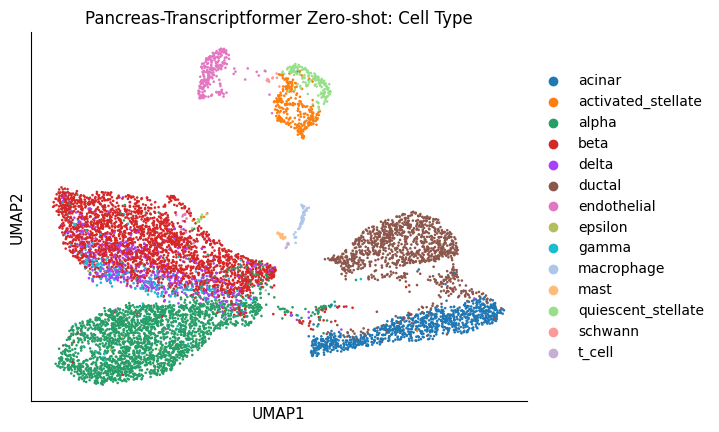

In [ ]:
ax = sc.pl.umap(
    adata,
    color='cell_type',
    frameon=True,
    title=[
        "Pancreas-Transcriptformer Zero-shot: Cell Type"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

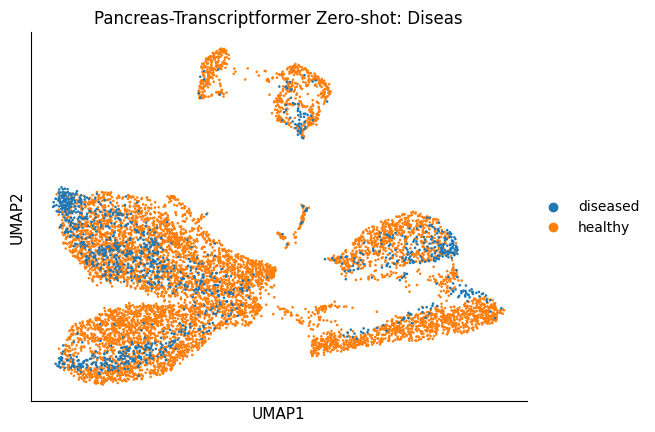

In [ ]:
ax = sc.pl.umap(
    adata,
    color='batch',
    frameon=True,
    title=[
        "Pancreas-Transcriptformer Zero-shot: Diseas"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Evaluate the integration performance

In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 0
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
label_keys = ["cell_type", "batch"]
scores = compute_silhouette_and_lisi_avg(adata, label_keys,embed_key="X_transcriptformer")

print("Silhouette scores:", scores["silhouette"])
print("LISI scores:", scores["lisi"])

Silhouette scores: {'cell_type': np.float32(0.013858082), 'batch': np.float32(0.055481322)}
LISI scores: {'cell_type': 1.25446217117197, 'batch': 1.202751424684703}


## Label Transfer

In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 0
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
adata.obs['batch'].value_counts()

,count
batch,
healthy,7266
diseased,1303


In [ ]:
train_data = adata[adata.obs['batch'] == 'healthy'].copy()
test_data  = adata[adata.obs['batch'] == 'diseased'].copy()

X_train = train_data.obsm["X_transcriptformer"]
X_test  = test_data.obsm["X_transcriptformer"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


In [ ]:
adata

AnnData object with n_obs × n_vars = 8569 × 0
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch', 'batch', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

=== Logistic Regression ===
Accuracy: 0.930928626247122
                    precision    recall  f1-score   support

            acinar       0.04      1.00      0.08         2
activated_stellate       1.00      0.98      0.99        52
             alpha       0.99      0.99      0.99       284
              beta       0.96      0.99      0.97       495
             delta       0.86      0.88      0.87       101
            ductal       1.00      0.82      0.90       280
       endothelial       1.00      1.00      1.00         7
           epsilon       0.25      1.00      0.40         1
             gamma       0.98      0.73      0.84        63
        macrophage       1.00      1.00      1.00        10
              mast       1.00      1.00      1.00         1
quiescent_stellate       0.83      1.00      0.91         5
           schwann       1.00      1.00      1.00         1
            t_cell       1.00      1.00      1.00         1

          accuracy                        

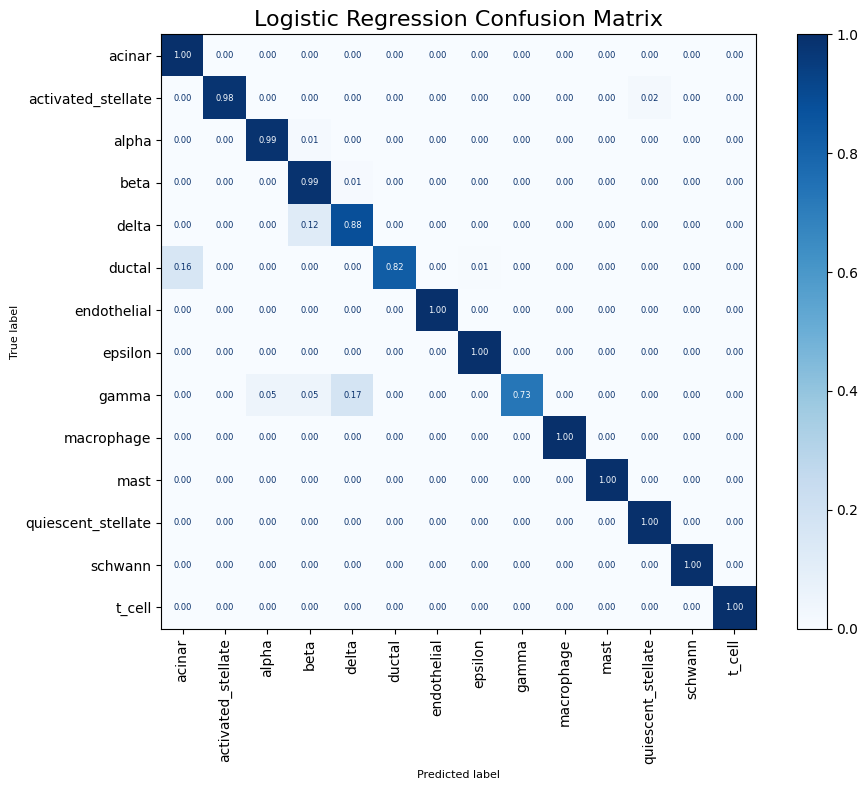


=== k-NN ===
Accuracy: 0.8810437452033768
                    precision    recall  f1-score   support

            acinar       0.04      1.00      0.07         2
activated_stellate       0.96      0.98      0.97        52
             alpha       0.95      0.98      0.96       284
              beta       0.92      0.96      0.94       495
             delta       0.71      0.71      0.71       101
            ductal       1.00      0.79      0.88       280
       endothelial       1.00      1.00      1.00         7
           epsilon       0.00      0.00      0.00         1
             gamma       0.69      0.43      0.53        63
        macrophage       1.00      1.00      1.00        10
              mast       1.00      1.00      1.00         1
quiescent_stellate       0.80      0.80      0.80         5
           schwann       0.00      0.00      0.00         1
            t_cell       1.00      1.00      1.00         1

          accuracy                           0.88      

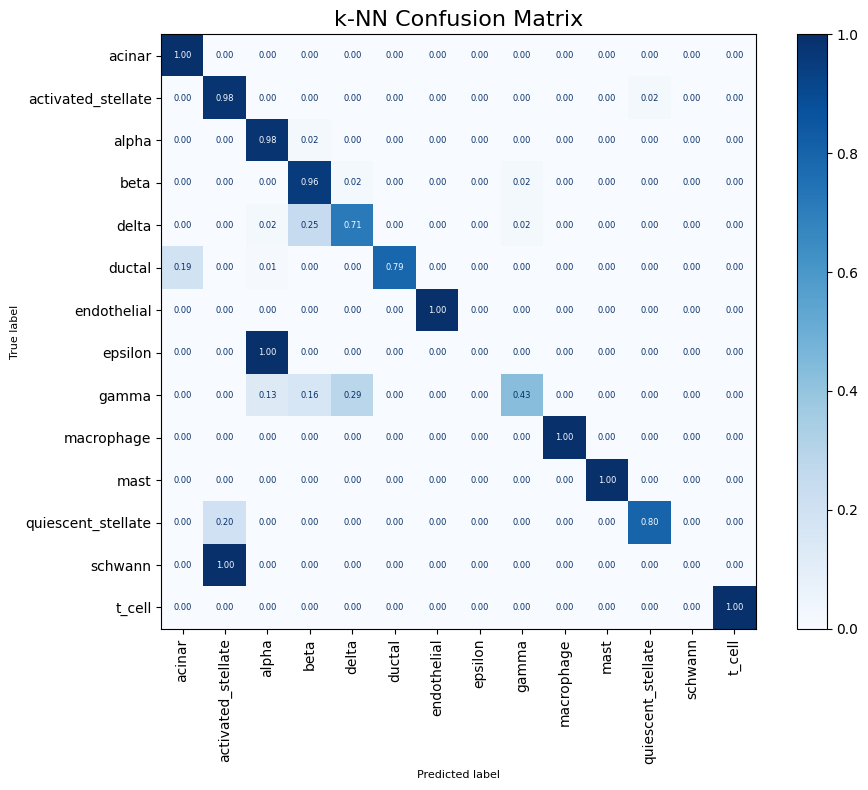

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

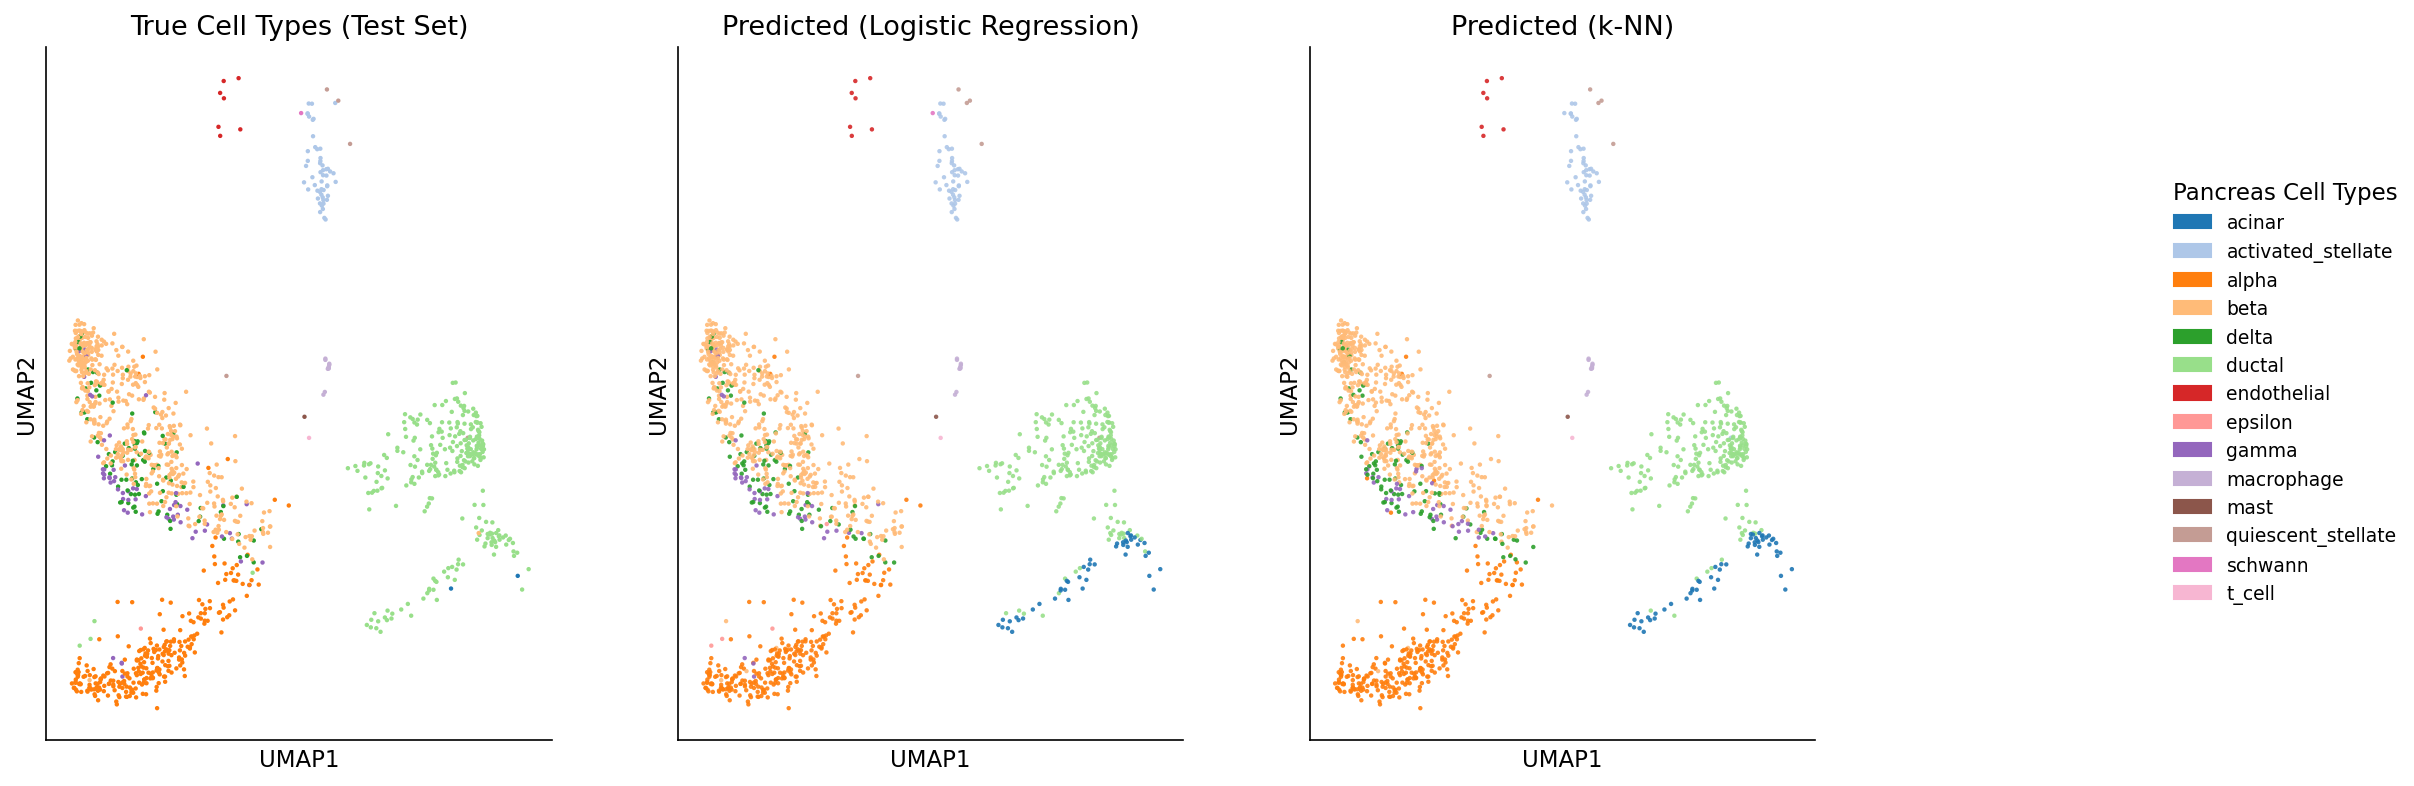

In [ ]:
# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category")
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.78, wspace=0.25)
plt.show()

# Pbmcs dataset Integration

In [ ]:
!mkdir -p /content/drive/MyDrive/gp/transcriptformer/integration/pbmcs

## Data preprocessing

In [ ]:
pbmcs_data_path = os.path.join(data_dir, "GP_datasets/PBMCs/combined_PBMCs_healthy_diseased_15k.h5ad")
adata = sc.read_h5ad(pbmcs_data_path)


In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 11895
    obs: 'disease', 'dataset', 'source'

In [ ]:
adata.var.index

Index(['SAMD11', 'PLEKHN1', 'HES4', 'ISG15', 'AGRN', 'C1ORF159', 'TTLL10',
       'TNFRSF18', 'TNFRSF4', 'SDF4',
       ...
       'S100B', 'PRMT2', 'MT-ND1', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6',
       'MT-CO3', 'MT-ND4', 'MT-ND6'],
      dtype='object', length=11895)

In [ ]:
mg = mygene.MyGeneInfo()

# Get gene symbols from index
gene_symbols = adata.var.index.tolist()

# Query Ensembl IDs
result = mg.querymany(gene_symbols, scopes='symbol', fields='ensembl.gene', species='human')

# Build a mapping dictionary
symbol_to_ensembl = {}
for r in result:
    if 'ensembl' in r:
        ensembl = r['ensembl']
        if isinstance(ensembl, list):
            symbol_to_ensembl[r['query']] = ensembl[0]['gene']
        else:
            symbol_to_ensembl[r['query']] = ensembl['gene']

# Add ensembl_id column
adata.var['ensembl_id'] = adata.var.index.map(symbol_to_ensembl)

# Check how many were mapped
print(f"Mapped: {adata.var['ensembl_id'].notna().sum()} / {len(adata.var)}")
print(adata.var.head())



INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-11895 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Mapped: 10608 / 11895
                 ensembl_id
SAMD11   ENSMUSG00000096351
PLEKHN1  ENSMUSG00000078485
HES4                    NaN
ISG15    ENSMUSG00000035692
AGRN     ENSMUSG00000041936


In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 11895
    obs: 'disease', 'dataset', 'source'
    var: 'ensembl_id'

In [ ]:
adata.obs['assay'] = '10x Genomics'


In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 11895
    obs: 'disease', 'dataset', 'source', 'assay'
    var: 'ensembl_id'

In [ ]:
adata.obs['disease'].unique()

['diseased', 'normal']
Categories (2, object): ['diseased', 'normal']

In [ ]:
adata.write(os.path.join(data_dir, "pbmcs/pbmcs.h5ad"))

## Get embeddings

In [ ]:
data="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/pbmcs/pbmcs.h5ad"
embeddings_dir="/content/drive/MyDrive/gp/transcriptformer/transcriptformer/integration/pbmcs"

In [ ]:
!transcriptformer inference --help

usage: transcriptformer inference [-h] --checkpoint-path CHECKPOINT_PATH
                                  --data-file DATA_FILE
                                  [--output-path OUTPUT_PATH]
                                  [--output-filename OUTPUT_FILENAME]
                                  [--batch-size BATCH_SIZE]
                                  [--gene-col-name GENE_COL_NAME]
                                  [--precision {16-mixed,32}]
                                  [--pretrained-embedding PRETRAINED_EMBEDDING]
                                  [--clip-counts CLIP_COUNTS]
                                  [--filter-to-vocabs]
                                  [--model-type {transcriptformer,esm2ce}]
                                  [--use-raw USE_RAW] [--emb-type {cell,cge}]
                                  [--remove-duplicate-genes]
                                  [--num-gpus NUM_GPUS]
                                  [--device {auto,cpu,cuda,mps}]
                   

In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 11895
    obs: 'disease', 'dataset', 'source', 'assay'
    var: 'ensembl_id'

In [ ]:
!transcriptformer inference \
    --checkpoint-path {model_dir} \
    --data-file {data} \
    --output-path {embeddings_dir} \
    --batch-size 8 \
    --remove-duplicate-genes \
    --output-filename transcriptformer_pbmcs_integration_embeddings.h5ad


 ___________  ___   _   _  _____           _       _  ______ ______________  ___ ___________
|_   _| ___ \/ _ \ | \ | |/  ___|         (_)     | | |  ___|  _  | ___ \  \/  ||  ___| ___ \
  | | | |_/ / /_\ \|  \| |\ `--.  ___ _ __ _ _ __ | |_| |_  | | | | |_/ / .  . || |__ | |_/ /
  | | |    /|  _  || . ` | `--. \/ __| '__| | '_ \| __|  _| | | | |    /| |\/| ||  __||    /
  | | | |\ \| | | || |\  |/\__/ / (__| |  | | |_) | |_| |   \ \_/ / |\ \| |  | || |___| |\ \
  \_/ \_| \_\_| |_/\_| \_/\____/ \___|_|  |_| .__/ \__\_|    \___/\_| \_\_|  |_/\____/\_| \_|
                                            | |
                                            |_|

2026-04-21 17:58:25,613 - INFO - Loading vocabulary file: /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs/assay
2026-04-21 17:58:25,614 - INFO - Loading ESM2 mappings from /content/drive/MyDrive/gp/transcriptformer/transcriptformer/transcriptformer/tf_exemplar/vocabs
2026-04-21 17:58:45,565 -

In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 11895
    obs: 'disease', 'dataset', 'source', 'assay'
    var: 'ensembl_id'

In [ ]:
adata = sc.read_h5ad(os.path.join(embeddings_dir,"transcriptformer_pbmcs_integration_embeddings.h5ad"))


In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 0
    obs: 'disease', 'dataset', 'source', 'assay'
    obsm: 'embeddings'

In [ ]:
adata.obsm['embeddings']

array([[-0.17279975,  0.35457888,  0.07879433, ...,  0.40392718,
         0.17994663,  0.140386  ],
       [ 0.06962497,  0.86207813,  0.5075841 , ...,  0.5225678 ,
         0.616948  ,  0.05495134],
       [-0.0431033 ,  0.51733255,  0.05449611, ...,  0.54722655,
         0.17727935, -0.05120546],
       ...,
       [-0.01820671,  0.13013384,  0.1645757 , ...,  0.27990276,
         0.11984907,  0.07685842],
       [-0.02609638,  0.2875217 ,  0.17627273, ...,  0.05267111,
         0.22866558,  0.01192192],
       [-0.05307209,  0.05253302,  0.11409184, ...,  0.3180813 ,
         0.12568235,  0.06386834]], shape=(14999, 2048), dtype=float32)

In [ ]:
adata.obsm['X_transcriptformer'] = adata.obsm.pop('embeddings')


In [ ]:
sc.pp.neighbors(adata, use_rep="X_transcriptformer")
sc.tl.umap(adata)

In [ ]:
adata.write(os.path.join(embeddings_dir,"transcriptformer_pbmcs_integration_embeddings.h5ad"))

## Visualize the integration performance

In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 0
    obs: 'disease', 'dataset', 'source', 'assay'
    uns: 'neighbors', 'umap'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

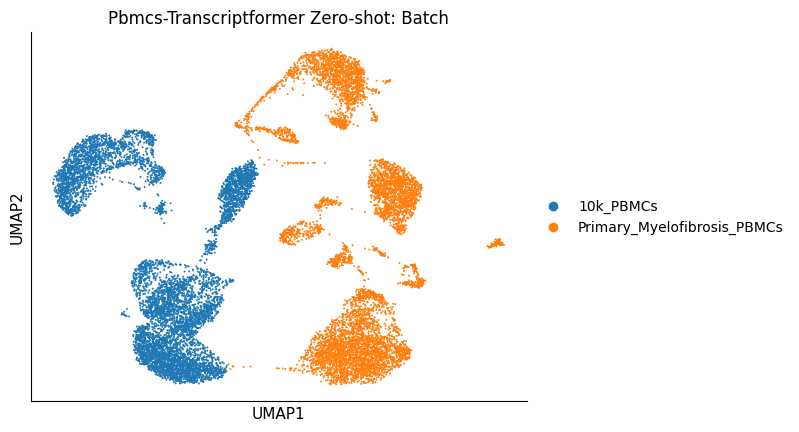

In [ ]:
ax = sc.pl.umap(
    adata,
    color='dataset',
    frameon=True,
    title=[
        "Pbmcs-Transcriptformer Zero-shot: Batch"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

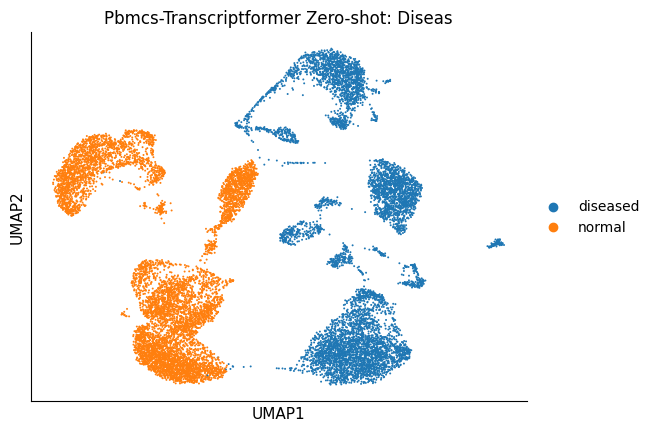

In [ ]:
ax = sc.pl.umap(
    adata,
    color='disease',
    frameon=True,
    title=[
        "Pbmcs-Transcriptformer Zero-shot: Diseas"],
    show=False,
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Evaluate the integration performance

In [ ]:
adata

AnnData object with n_obs × n_vars = 14999 × 0
    obs: 'disease', 'dataset', 'source', 'assay'
    uns: 'neighbors', 'umap', 'dataset_colors', 'disease_colors'
    obsm: 'X_transcriptformer', 'X_umap'
    obsp: 'connectivities', 'distances'

In [ ]:
label_keys = ["disease"]
scores = compute_silhouette_and_lisi_avg(adata, label_keys,embed_key="X_transcriptformer")

print("Silhouette scores:", scores["silhouette"])
print("LISI scores:", scores["lisi"])

Silhouette scores: {'disease': np.float32(0.3779796)}
LISI scores: {'disease': 1.0}
